# Laboratory 10: VQGAN: Converting images into sequences of integers

This laboratory covers

* Encoding images into continuous latent representations.
* Quantizing these latent representations into discrete codes using a codebook.
* Reconstructing images from discrete sequences.
* Understanding perceptual loss, adversarial loss, and quantization loss.

Vector quantized generative adversarial network (VQGAN), introduced by Esser et al. (2021), is an advanced generative model combining the strengths of generative adversarial networks (GANs) and vector quantized variational autoencoders (VQ-VAEs). Specifically designed for high-resolution image synthesis, VQGAN utilizes the powerful generative capabilities of GANs alongside the structured, efficient latent representations introduced by VQ-VAEs.

GANs are renowned for producing highly realistic images by training two neural networks, a generator and a discriminator, in an adversarial manner. The generator aims to create realistic images, while the discriminator learns to differentiate between real and generated images (considered fake). However, GANs often face training instabilities and have less interpretable latent spaces. VQ-VAEs address these challenges by discretizing continuous latent representations into discrete codes using a learned codebook. This quantization helps produce compact, meaningful, and interpretable latent representations, making VQ-VAEs especially useful in applications involving structured symbolic reasoning, such as Transformer-based models.

By integrating these two paradigms, VQGAN achieves the best of both worlds: it maintains a structured and interpretable latent space through quantization and benefits from adversarial training to generate high-quality, realistic images. The VQGAN architecture consists of a VQ-VAE generator and a discriminator. The VQ-VAE generator first uses an encoder to transform images into continuous latent representations. It then uses a quantizer to discretize these latent representations using a codebook. Finally, it uses a decoder to reconstruct images from the quantized codes. The discriminator in VQGAN adversarially guides the VQ-VAE generator toward producing increasingly realistic outputs.

In this laboratory, we will first explore the foundational concepts behind GANs and VQ-VAEs to gain a deeper understanding of their synergies. We will then learn how to use a pretrained VQGAN model to reconstruct images and convert them into sequences of integers. This discrete sequence representation is a critical feature of cutting-edge text-to-image models such as DALL-E, which treat images as sequences of tokens, similar to words in a sentence, allowing Transformer architectures to model visual data.

By the end of this laboratory, we will not only understand the architecture and training process of VQGANs, but also how to reconstruct images step by step from discrete latent codes. This prepares us to dive into the next laboratory, where we will build a mini version of DALL-E and turn text prompts into images, with the help of the VQGAN model.

#1. Converting images into sequences of integers and back

VQGAN, introduced by Esser et al. (2021), merges the strengths of GANs and
VQ-VAEs. GANs excel at producing realistic and high-quality images through
adversarial training between two neural networks: a generator and a discriminator.
However, GANs often face training instabilities and produce latent spaces that lack
interpretability. VQ-VAEs, on the other hand, address these issues by quantizing continuous
latent representations into discrete, interpretable codes via a learned codebook.
This discretization process results in more stable training and structured latent
spaces that are particularly suitable for symbolic reasoning tasks, such as Transformer-based
modeling. That said, pure GANs can still be preferred in scenarios where maximum
photorealism is the primary goal and where interpretability or latent-space
structure is less critical.

The ability of VQGAN to convert an image into a sequence of integers and then back
into an image is crucial for Transformer-based text-to-image generation models. To give
us a taste of what a VQGAN model can accomplish, we first treat it as a black box.
We will use a pretrained VQGAN to convert an image to a sequence of integers.

To get started, run the following command to install the required libraries:

In [ ]:
!pip install omegaconf pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.5 MB/s eta 0:00:00


Download the image [`fish.png`](https://drive.google.com/file/d/1juhYfiNUx6td1AwJ3hFIxGXAZEhGtdY2/view?usp=drive_link), and place it in
the `files` folder.

We will use the pretrained VQGAN model developed by the Computer Vision and
Learning research group at Ludwig Maximilian University of Munich through its
GitHub repository. Due to changes in PyTorch, the repository requires small updates to remain compatible. This was done in the following repository:

In [ ]:
!git clone https://github.com/markhliu/taming-transformers

Cloning into 'taming-transformers'...
remote: Enumerating objects: 1236, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 1236 (delta 1), reused 1 (delta 1), pack-reused 1230 (from 2)
Receiving objects: 100% (1236/1236), 148.34 MiB | 37.61 MiB/s, done.
Resolving deltas: 100% (257/257), done.


After this completes, we should see a new folder named `taming-transformers` in
the working directory. To make sure Python can access and import modules from this
repository, we add this folder to Python's search path using the `sys` library:

In [ ]:
import sys
sys.path.append("./taming-transformers")

The following code loads the pretrained VQGAN model and converts the fish
image into a sequence of integers. The model then converts the sequence back into a
fish image.

In [ ]:
import requests, os

url1=('https://heibox.uni-heidelberg.de/f/'
      '140747ba53464f49b476/?dl=1')
url2=('https://heibox.uni-heidelberg.de/f/'
      '6ecf2af6c658432c8298/?dl=1')

file1="files/vqgan_imagenet_f16_1024.ckpt"
file2="files/vqgan_imagenet_f16_1024.yaml"    #Defines URLs and filenames for the model weights and configuration

if not os.path.exists(file1):
    fb=requests.get(url1)
    with open(file1,"wb") as f:
        f.write(fb.content)    #If the weights file is missing, download it from the specified URL.

if not os.path.exists(file2):
    fb=requests.get(url2)
    with open(file2,"wb") as f:
        f.write(fb.content)    #If the configuration file is missing, download it from the specified URL.

In [ ]:
import torch
torch.set_grad_enabled(False)    #Disables gradient computation to speed up inference

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from omegaconf import OmegaConf
from taming.models.vqgan import VQModel

def load_model():
    config = OmegaConf.load(file2)    #Loads model configuration
    model = VQModel(**config.model.params).to(device)    #Imports the VQGAN model from the GitHub repository
    sd = torch.load(file1)["state_dict"]
    missing, unexpected = model.load_state_dict(sd,
                            strict=False)    #Loads pretrained weights to the VQGAN model
    return model

In [ ]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #Defines a process_image() function to center crop images and resize them
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

def image_to_sequence(model,image):
    z=model.encoder(image.to(device))
    z=model.quant_conv(z)
    z_q, _ , indices= model.quantize(z)
    int_sequence = indices[2]
    return int_sequence

def sequence_to_image(model,sequence):
    z_q2 = model.quantize.embedding(sequence)
    z_q2 = z_q2.permute(1,0).view((1,256,24,24))
    z_post2 = model.post_quant_conv(z_q2)
    z_recon2 = model.decoder(z_post2)
    return z_recon2

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
the image is converted to:
 tensor([ 508,  343,  261,  508,  156,  596,  634,  534,  508,  501,  253,  970,
         881,  500,  508,  500,  873,  433,  976,  294,   29,  455,  455,  717,
         110,  154,  556,  941,  909,  542,  156,  601,  869,  856,  187,  911,
         168,  534,  705,  261,  965,  313,  553,  903,  171,  862,  154,  623,
         312, 1019,  556,  156,  156,  460,  503,  642,  992,  966,  192,  222,
         556,  856,  856,  460,  909,  363,  634,  577,  972,  156,  681,  316,
         343,  556,  343,  514,  287,  438,  587,  772,  588,  671,  787,  129,
         764,  255,  990,  156,  593,  634,  164,  590,  639,  542,  156,  884,
         705,  990,  810,  333,    7,  662,  772,  109,   84,  932,  494,  936,
         857,  373,  788,  556,   20,  909,  601,  903,  970,  903

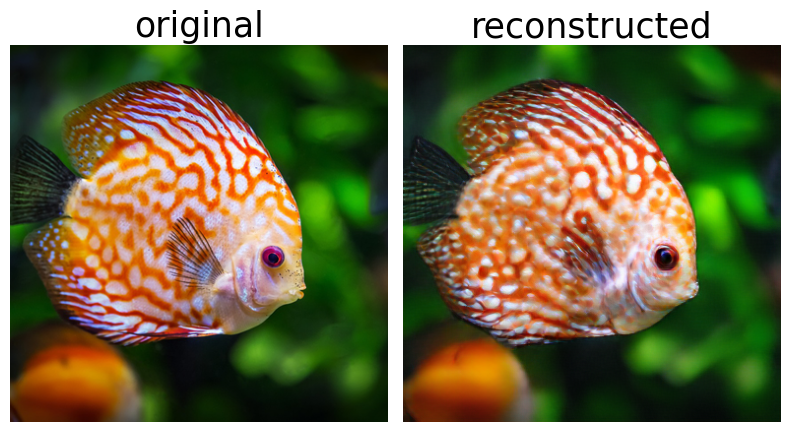

In [ ]:
import matplotlib.pyplot as plt

model=load_model()    #Loads the pretrained VQGAN (may take a few minutes)
image=process_image("files/fish.png")
sequence=image_to_sequence(model,image)    #Converts the image into a sequence of integers
print("the image is converted to:\n", sequence)    #Prints out the sequence
reconstruct=sequence_to_image(model,sequence)    #Reconstructs the image based on the sequence
imgs=[image[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct[0].cpu().permute(1,2,0)*0.5+0.5]
captions=["original","reconstructed"]
plt.figure(figsize=(8,5),dpi=100)
for i in range(2):    #Displays the original and reconstructed images
    plt.subplot(1,2,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=25)
    plt.axis('off')
plt.tight_layout()
plt.show()

We start by loading a pretrained VQGAN model using the `load_model()` function. This initial step may require several minutes,
as it involves downloading a large pretrained weights file exceeding 1 GB in size.

Next, the model converts the input fish image into a discrete sequence of integers.
The resulting sequence is illustrated above.

This sequence consists of $576$ integers
(we will explain the reason behind
this specific number shortly). The
pretrained VQGAN model then
reconstructs a high-resolution image
from this integer sequence, closely
resembling the original fish image.

#2. A pretrained VQGAN model

In this section, we will work with a pretrained VQGAN model from the `taming-transformers` GitHub repository. We will start by learning
how to reconstruct a simple image of a cat using the model. From there, we will dive
deeper into the reconstruction process.

First, we will learn the encoding process: the cat image is transformed into a set of
latent vectors. We will then map these latent vectors to discrete representations by finding
the nearest feature vectors in a codebook, a process known as quantization. This allows
us to represent the original image as a sequence of integers, where each integer corresponds
to the index of a feature vector in the codebook. Finally, we will reverse the process
by decoding this sequence of integers back into a full image, demonstrating how
VQGAN enables efficient compression and reconstruction of visual data.

##2.1. Reconstructing images with the pretrained VQGAN

The GitHub repository we cloned earlier contains the VQGAN implementation.
First, we will download the pretrained weights and model configuration files for
VQGAN. This will allow us to reconstruct images and explore how VQGAN encodes
them into latent representations:

In [ ]:
import requests, os

url1=('https://heibox.uni-heidelberg.de/f/'
      '140747ba53464f49b476/?dl=1')
url2=('https://heibox.uni-heidelberg.de/f/'
      '6ecf2af6c658432c8298/?dl=1')

file1="files/vqgan_imagenet_f16_1024.ckpt"
file2="files/vqgan_imagenet_f16_1024.yaml"    #Defines URLs and filenames for the model weights and configuration

if not os.path.exists(file1):
    fb=requests.get(url1)
    with open(file1,"wb") as f:
        f.write(fb.content)    #If the weights file is missing, download it from the specified URL.

if not os.path.exists(file2):
    fb=requests.get(url2)
    with open(file2,"wb") as f:
        f.write(fb.content)    #If the configuration file is missing, download it from the specified URL.

The code block first checks whether the pretrained weights and model configuration
files already exist in our local directory. If they are missing, the code will automatically
download them from the provided URLs. Once these files are in place, we can import
the VQGAN model directly from the cloned GitHub repository.

In [ ]:
import torch
torch.set_grad_enabled(False)    #Disables gradient computation to speed up inference

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from omegaconf import OmegaConf
from taming.models.vqgan import VQModel

config = OmegaConf.load(file2)    #Loads model configuration
model = VQModel(**config.model.params).to(device)    #Imports the VQGAN model from the GitHub repository
sd = torch.load(file1)["state_dict"]
missing, unexpected = model.load_state_dict(sd,
                        strict=False)    #Loads pretrained weights to the VQGAN model

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.


We import the VQGAN model from the GitHub repository and instantiate a model
based on the model specifications in the file `vqgan_imagenet_f16_1024.yaml` that we
downloaded earlier. We then load the pretrained weights into the model so that we can
reconstruct images using the model later.

To understand how the VQGAN model reconstructs images step by step, we will use
two images as our examples. Place the [`cat.png`](https://drive.google.com/file/d/1yuhkdo6mCjV1Lage2eTT5WIbi0HXo0yz/view?usp=drive_link) and [`fish.png`](https://drive.google.com/file/d/1juhYfiNUx6td1AwJ3hFIxGXAZEhGtdY2/view?usp=drive_link) images in the `files` folder.

In [ ]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #Defines a process_image() function to center crop images and resize them
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

image1=process_image("files/cat.png")
image2=process_image("files/fish.png")    #Applies the process_image() function on the cat and fish images
print(f"the shape of the original image is {image1.shape}")
reconstruct1=model((image1).to(device))[0]
reconstruct2=model((image2).to(device))[0]    #Reconstructs the cat and fish images using the pretrained VQGAN
print(f"reconstructed image's shape is {reconstruct2.shape}")

the shape of the original image is torch.Size([1, 3, 384, 384])
reconstructed image's shape is torch.Size([1, 3, 384, 384])


We first define a `process_image()` function to process images. The function loads an
image from the local folder, center-crops the image, resizes it to $3 \times 384 \times 384$, and
converts it into a PyTorch tensor. We apply the function to the cat and fish images and
name the processed images `image1` and `image2`, respectively. We feed the two processed
images to the pretrained VQGAN to obtain two reconstructed images, `reconstruct1`
and `reconstruct2`.

We plot the two original images and the two reconstructed ones in a $1 \times 4$ grid, as
shown here.

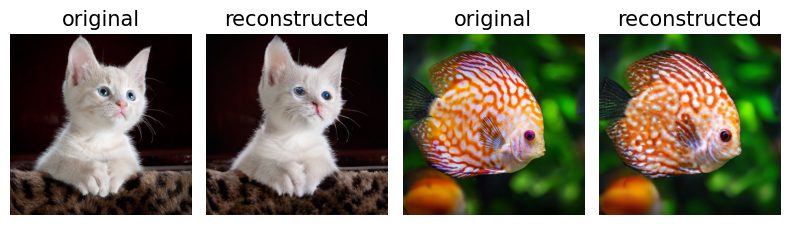

In [ ]:
import matplotlib.pyplot as plt

imgs=[image1[0].cpu().permute(1,2,0)*0.5+0.5,    #Places the two originals and the two reconstructed images in a list
      reconstruct1[0].cpu().permute(1,2,0)*0.5+0.5,
      image2[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"]*2    #Prepares four captions

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()

We place the two original images and the two reconstructed ones in a list `imgs`. We
then plot the four images in a $1 \times 4$ grid and put a caption of either `original` or `reconstructed`
above each image.

The two reconstructed images are similar to the two originals, but we
can easily see the difference. Some information is lost in the reconstruction process.
Part of the reason is the quantization process: we use $1,024$ discrete latent vectors in
the codebook to approximate the actual latent vectors. Because the two sets of vectors
are not identical, some information is lost in the quantization process.

Next, we will dive deeper and examine how the model encodes the images and quantizes
the latent vectors. We will also investigate how the model translates the quantized
latent vectors into a sequence of integers and converts the sequence back into an
image.

##2.2. Converting images into sequences of integers

We will use the cat image we downloaded earlier as an example to show, step-by-step,
how the VQGAN model reconstructs an image. The VQGAN model first encodes the
input image into a latent representation. This is done using the model's encoder, followed
by a linear projection layer (`quant_conv`). The process looks like this:

In [ ]:
z=model.encoder(image1.to(device))
z=model.quant_conv(z)
print(f"the shape of the latent representation is {z.shape}")

the shape of the latent representation is torch.Size([1, 256, 24, 24])


This output tensor, `z`, is the latent representation of the image. The output shows that
`z` has a shape of `[1, 256, 24, 24]`:
* The first dimension ($1$) indicates a single image in the batch.
* The second dimension ($256$) represents the number of feature channels.
* The last two dimensions ($24 \times 24$) represent the spatial resolution of the latent
image.

We may be wondering why the latent representation has a resolution of $24 \times 24$. This
is because the encoder uses four strided convolutional layers, and each of these layers
reduces the spatial resolution by a factor of $2$. Therefore, the encoder has a total
downsampling factor of $2^4 = 16$. The original image has a resolution of $384 \times 384$; as
a result, the encoded image has a resolution of $24 \times 24$ because $384 ÷ 16 = 24$. Thus,
the encoded image now has $24 \times 24 = 576$ patches. Each patch is represented by a
$256$-dimensional feature vector, explaining the overall shape of `[1, 256, 24, 24]`.

The next step is to quantize the latent vectors. VQGAN maintains a codebook with
$1,024$ learnable vectors. During quantization, each feature vector in the latent space
is replaced with the nearest vector from this codebook. This discretization allows the
model to compress continuous latent vectors into discrete representations. The quantization
process is performed as follows:

In [ ]:
z_q, _ , indices= model.quantize(z)    #Quantizes the latent vectors by replacing each one with its nearest neighbor in the codebook
int_sequence = indices[2]    #Extracts the sequence of integers (indices of the selected codebook vectors)
print(int_sequence)

tensor([ 873,  862,  873,  862,  862,   63,  110,  455,  590,  481,   29,  813,
         455,  813,  812,  813,  862,  862,   96,  862,  862,   63,   96,   96,
         312,   96,  894,  556,  717,   36,  812,  717,  742,  790,  350,  455,
         946,  937,  154,  772,  455,  813,  979,  110,  812,  813,  868,  717,
         862,  154,  862,  110,  154,  812,  325,  438,  875,  200,  669,   63,
         630,  404,  993,  623,  572,  668,  376,  520,  110,  623,  873,  325,
         523,  312,  623,  110,  937,  812,  623,  771,  585,  577,  119,  172,
         910,  520,  717,  862,  956,   35,   36,  590,  813,  993,  701,  701,
          96,  325,  450,  256,  168,  154,  455,  184,  816,  932,  237,   31,
         849,  479,  343,  575,  628,  185,  534,  261,  325,  862,  937,  873,
         590,  154,  325,  110,  710,  937,  813,  444,   39,  550,  350,  610,
         136,  354,  578,  301,  175,  706,  807,  450,  330,  168,  718,  312,
          96,  993,   63,  813,  154,  7

Now the latent representation (`z`) are represented by the nearest vectors in the codebook,
`z_q`. Further, the latent representation can be converted into a sequence of $576$
integers, shown above.

The shape of the latent representation `z` is $(256, 24, 24)$, meaning the image is represented
by $576$ patches in a $24 \times 24$ grid with each patch represented by a $256$-value
feature vector. We then match each of the $576$ vectors with the nearest vector in the
codebook. Therefore, each of the $576$ vectors can be assigned an index, where the
index is the corresponding discrete vector in the codebook. The result is a sequence
of $576$ integers, each representing a specific vector in the codebook that approximates
the original latent vector.

The first two integers in the sequence are $873$ and $862$. This
indicates the following:
* The first feature vector in the latent grid is closest to vector $873$ in the codebook.
* The second feature vector is nearest to the codebook vector $862$.

With this sequence of integers and access to the codebook, we can reconstruct
the quantized latent representations, denoted as `z_q`. Each integer simply serves as a pointer to a specific vector in the codebook, allowing us to rebuild the entire quantized
latent grid.

Importantly, the VQGAN decoder is capable of performing the reverse operation: it
takes this sequence of integers (representing codebook indices) and reconstructs the
corresponding image. This ability to map discrete sequences back into visual data is
foundational for models such as DALL-E, which generate images from sequences of integers
derived from text prompts. We will explore this concept further in the next laboratory.

Given a sequence of
$576$ integers, we can reconstruct the corresponding image using the VQGAN codebook
and decoder. The process begins by mapping each integer in the sequence to its corresponding
feature vector in the codebook. For instance, if the first two integers in the
sequence are $873$ and $862$, they point to vectors $873$ and $862$ in the codebook, respectively.
By retrieving all $576$ feature vectors in this way, we assemble a complete quantized
latent representation, which we will call `z_q2`.

Once `z_q2` is formed, we can pass it through the VQGAN decoder to reconstruct the
image. The process is implemented as follows:

In [ ]:
z_q2 = model.quantize.embedding(int_sequence)
z_q2 = z_q2.permute(1,0).view(z_q.shape)    #Builds a quantized latent representation, z_q2, based on the sequence of integers
z_post2 = model.post_quant_conv(z_q2)
z_recon2 = model.decoder(z_post2)    #Converts the latent representation into an image using the VQGAN decoder

We use the VQGAN decoder to convert the quantized latent representation `z_q2` into a
reconstructed image, `z_recon2`.

We can compare `z_recon2` with the one reconstructed based on `z_q`:

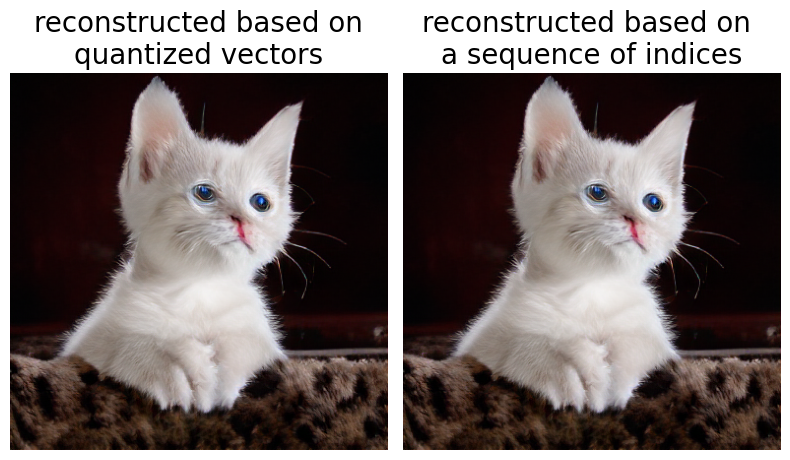

In [ ]:
z_post = model.post_quant_conv(z_q)
z_recon = model.decoder(z_post)    #Reconstructs the cat image using the quantized latent representation, z_q

imgs=[z_recon[0].cpu().permute(1,2,0)*0.5+0.5,
      z_recon2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["reconstructed based on\nquantized vectors",
          "reconstructed based on \na sequence of indices"]

plt.figure(figsize=(8,5),dpi=100)
for i in range(2):    #Compares the reconstructed image based on z_q to the image based on the sequence of indices
    plt.subplot(1,2,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=20)
    plt.axis('off')
plt.tight_layout()
plt.show()

The image `z_recon` is reconstructed based on the quantized representation `z_q`. We
compare it with the reconstructed image based on the sequence of integers.

The two identical
reconstructed images
demonstrate
VQGAN’s capability
to regenerate an image solely
from a sequence of integers. This
ability to convert discrete token
sequences back into high-quality
images is a foundational feature
in state-of-the-art text-to-image
models such as DALL-E.

#Exercises

1. Download the two images, [`bird.png`](https://drive.google.com/file/d/17al7QkCrihd1_vYPenS0YmOvKbyS0jB1/view?usp=drive_link) and [`bunny.png`](https://drive.google.com/file/d/1t7WnYrrwnUxbMZ38Cv6Gv41n-tVKjyHF/view?usp=drive_link). Place the two images in the
`files` folder. Use the `process_image()` function to process the
two images, and name the processed images `image3` and `image4`, respectively. Feed
the two processed images to the pretrained VQGAN to obtain two reconstructed
images, `reconstruct3` and `reconstruct4`.

2. Place the two original images, `image3` and `image4`, and the two reconstructed ones,
`reconstruct3` and `reconstruct4`, in a list `imgs`. Plot the four images in a $1 \times 4$ grid,
and add a caption of either `original` or `reconstructed` above each image.

3. Find out the quantized latent representation for the fish image, and name it `z2_q`. Find
out the sequence of integers that represent the fish image, and call it `int_sequence2`.
Print out the $576$ values in `int_sequence2`.

4. Map each integer in `int_sequence2` to its corresponding feature vector in the codebook
to assemble a complete quantized latent representation `z2_q2`. Pass `z2_q2`
through the VQGAN decoder to reconstruct the fish image, and name the reconstructed
image `z2_recon2`.

5. First, reconstruct the fish image based on the quantized latent representation first generated, `z2_q`, in Exercise 3, and name the reconstructed fish image `z2_recon`. Plot `z2_recon` and `z2_recon2` side by side in a $1 \times 2$ grid to compare them.